<a href="https://colab.research.google.com/github/BernardoBremer/Inteligencia-Computacional-Cetys-/blob/main/5_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random
import torch.nn as nn
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 50000
Test samples: 10000


In [4]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def show(img_tensor, label):
    img = img_tensor.permute(1, 2, 0).numpy()
    plt.figure(figsize=(5, 5))
    plt.title(CLASSES[label], fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(img)

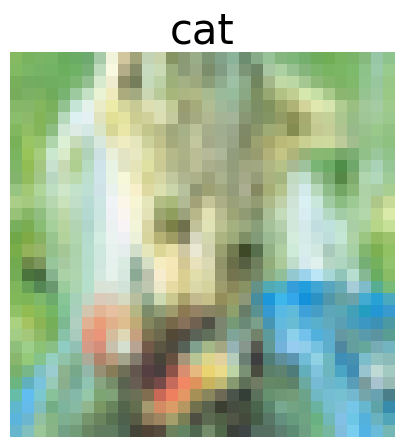

In [5]:
rnd_idx = random.randint(0, len(train_data) - 1)
image, label = train_data[rnd_idx]
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [6]:
IMG_HEIGHT   = 32
IMG_WIDTH    = 32
IMG_CHANNELS = 3

In [7]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [8]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [9]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [10]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [11]:
model_1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_CHANNELS * IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_1 = model_1.to(device)

In [12]:
epochs = 15
loss_function = nn.CrossEntropyLoss()
optimizer_1 = Adam(model_1.parameters())

res_1 = train(model_1, train_loader, test_loader, loss_function, optimizer_1, epochs)

Training: 100%|██████████| 15/15 [02:59<00:00, 11.94s/epoch, train_acc=0.5356, train_loss=1.2950, val_acc=0.4922, val_loss=1.4303]


In [13]:
test_loss_1, test_acc_1 = test(model_1, test_loader, loss_function)
print(f"FCNN - Test Loss: {test_loss_1:.4f}, Test Accuracy: {test_acc_1:.4f}")

FCNN - Test Loss: 1.4303, Test Accuracy: 0.4922


### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [14]:
model_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_2 = model_2.to(device)

In [15]:
optimizer_2 = Adam(model_2.parameters())

res_2 = train(model_2, train_loader, test_loader, loss_function, optimizer_2, epochs)

Training: 100%|██████████| 15/15 [03:37<00:00, 14.47s/epoch, train_acc=0.8602, train_loss=0.3848, val_acc=0.7688, val_loss=0.7478]


In [16]:
test_loss_2, test_acc_2 = test(model_2, test_loader, loss_function)
print(f"CNN - Test Loss: {test_loss_2:.4f}, Test Accuracy: {test_acc_2:.4f}")

CNN - Test Loss: 0.7478, Test Accuracy: 0.7688


### CNN model 3

Third architecture using Batch Normalization after each convolutional layer for more stable training.

In [17]:
model_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.3),
    nn.Linear(512, 10)
)

model_3 = model_3.to(device)

In [18]:
optimizer_3 = Adam(model_3.parameters())

res_3 = train(model_3, train_loader, test_loader, loss_function, optimizer_3, epochs)

Training: 100%|██████████| 15/15 [03:40<00:00, 14.70s/epoch, train_acc=0.9291, train_loss=0.1991, val_acc=0.7735, val_loss=0.9380]


In [19]:
test_loss_3, test_acc_3 = test(model_3, test_loader, loss_function)
print(f"Deep CNN - Test Loss: {test_loss_3:.4f}, Test Accuracy: {test_acc_3:.4f}")

Deep CNN - Test Loss: 0.9380, Test Accuracy: 0.7735


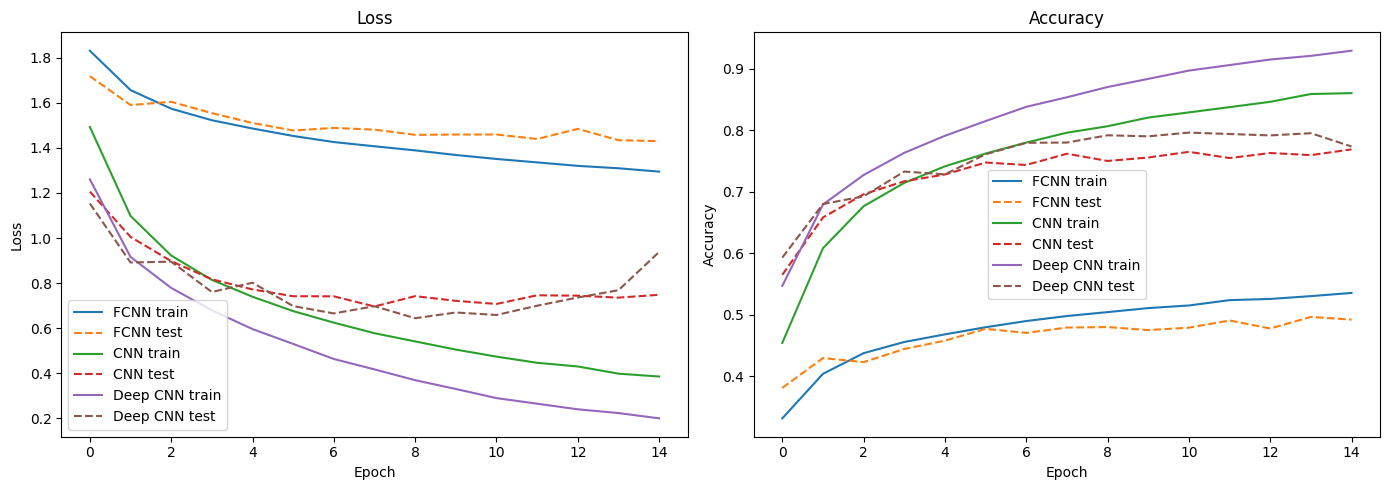

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for res, label in [(res_1, "FCNN"), (res_2, "CNN"), (res_3, "Deep CNN")]:
    axes[0].plot(res['train_loss'], label=f"{label} train")
    axes[0].plot(res['val_loss'], '--', label=f"{label} test")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

for res, label in [(res_1, "FCNN"), (res_2, "CNN"), (res_3, "Deep CNN")]:
    axes[1].plot(res['train_acc'], label=f"{label} train")
    axes[1].plot(res['val_acc'], '--', label=f"{label} test")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
results = {"FCNN": test_acc_1, "CNN": test_acc_2, "Deep CNN": test_acc_3}
best_name = max(results, key=results.get)

print("Test Accuracy:")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f}")
print(f"\nBest model: {best_name} with {results[best_name]:.4f} accuracy")

Test Accuracy:
  FCNN: 0.4922
  CNN: 0.7688
  Deep CNN: 0.7735

Best model: Deep CNN with 0.7735 accuracy


## Reflection section

### Learning curves
Las curvas de aprendizaje nos muestran como se va portando cada modelo conforme avanzan las epocas. Se nota que el FCNN agarra rapido en train pero su loss en test se va bien arriba, o sea que nomas esta memorizando los datos en vez de aprender patrones que sirvan. Los CNNs se portan mejor en general, sobre todo el Deep CNN que mantiene un gap mas chiquito entre train y test.

### Which model is better at classifying images?

El mejor modelo fue el Deep CNN. Tiene sentido porque al tener mas conv layers puede agarrar patrones mas detallados de las imagenes como edges, texturas y shapes. El FCNN nomas hace flatten de toda la imagen y pierde la informacion espacial, por eso le batalla mas para clasificar bien.

### Which model was _faster_ to train?
El FCNN fue el mas rapido en tiempo por epoca, ya que no tiene operaciones de convolucion que son mas pesadas. Pero pues los CNNs no tardaron tanto mas y la mejora en accuracy si lo vale. Entre el CNN y el Deep CNN, el CNN simple fue un poco mas rapido porque tiene menos layers y menos parametros.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

Lo que mas se nota es que el FCNN tiene un overfitting muy alto, su train loss baja mucho pero el test loss sube, o sea que la red nomas se esta aprendiendo de memoria los training examples. El CNN basico se porta mas estable, las curvas de train y test van mas o menos parejas aunque si hay separacion. El Deep CNN es el que mejor generaliza, las curvas estan mas juntas y el accuracy en test es el mas alto de los tres.

### How many trainable parameters does each model have?


FCNN: Tiene 3 linear layers. La primera recibe 3072 (3x32x32) y sale 512, la segunda 512 a 256 y la tercera 256 a 10. En total andan como 1,704,202 parametros aprox.

CNN: Tiene 3 conv layers y 2 linear layers. Es mas eficiente porque los filters comparten weights, entonces tiene menos parametros que el FCNN aunque tenga mas layers.

Deep CNN: Tiene 4 conv layers y 2 linear layers. Tiene mas parametros que el CNN simple por las layers extra y los filters mas grandes (64 y 128), pero la mayoria estan en la linear layer de 128*8*8 a 512.

### How do the models compare in terms of overfitting? Why do you think that is the case?

FCNN es el que mas overfitting tiene, y pues creo que es porque al hacer flatten de la imagen pierde toda la estructura  y termina memorizando patrones que no le sirven para generalizar. Aparte tiene muchos parametros en las dense layers.

El CNN simple tiene menos overfitting gracias a que las convolutions agarran local features y el dropout le ayuda a regularizar. El Deep CNN tambien se comporta bien aunque con mas epochs probablemente empezaria a hacer overfit tambien porque tiene muchos parametros.

### Final conclusions and remarks
Esta actividad estuvo intersante porque pude ver en practica la diferencia entre usar una red fully connected vs una convolucional para imagenes. Siempre habia leido que las CNNs son mejores para vision pero verlo en las graficas y los numeros es otra cosa. Me sorpendio que con solo meterle mas conv layers al Deep CNN la mejora fue muyy notable comparado con el CNN basico.

### Uso de herramientas de IA

Para esta actividad utilize Gemini como apoyo en las siguientes partes:

- Conversion de imagenes a tensores: Investigue como convertir las imagenes PIL que carga cifar10 por default a tensores de PyTorch. Gemini me ayudo a enteder que se usa transforms.ToTensor() dentro de un transforms.Compose y que eso se pasa como parametro transform al cargar el dataset.
- Curvas de aprendizaje: Para la parte de graficar las curvas comparando train vs test me apoye en Gemini para saber como armar los subplots con matplotlib y como acomodar las graficas de loss y accuracy lado a lado.

El resto del codigo como las arquitecturas de las redes, el training loop y la evaluacion fue desarrollado con base en lo visto en clase e intercambio de conocimiento con mis companeros de clase